# 16. Optimization — Collection / Resource Allocation

## Business Case

A bank has a portfolio of overdue customers.

The collection team has limited resources:

- limited call-center capacity,
- limited field-agent capacity,
- limited digital campaign budget.

The business question is:

> **How should limited collection resources be allocated to maximize expected recovery?**

This is an **Optimization** problem.

The objective is not simply to predict who will pay.

Instead:

```text
Predictions
    ↓
Expected recovery
    ↓
Costs + constraints
    ↓
Optimization
    ↓
Best allocation
```

This notebook uses synthetic banking data for educational purposes.

## 1. Prediction vs Optimization

### Prediction

Question:

> How much might we recover from this customer?

Output:

```text
Expected Recovery = Rp 2,500,000
```

### Optimization

Question:

> Given only 650 call-center slots and 300 field-agent slots, which customers should receive those resources?

Optimization considers:

```text
Expected benefit
+
Resource cost
+
Business constraints
```

The distinction is important:

> **Machine Learning predicts. Optimization decides how to allocate resources under constraints.**

## 2. Banking Collection Example

Suppose:

```text
10,000 overdue customers

Resources:
650 call slots
300 field-agent visits
Rp 7.5 billion digital budget
```

A naive strategy may prioritize the largest overdue balance.

But that can be suboptimal.

For example:

```text
Customer A
Overdue = Rp 100m
Expected recovery = Rp 2m

Customer B
Overdue = Rp 20m
Expected recovery = Rp 10m
```

Customer B may create more expected recovery despite having a smaller balance.

Optimization makes the trade-off explicit.

## 3. Decision Variables

For each customer, define:

```text
x_i,c = 1
```

if customer `i` receives collection channel `c`.

Otherwise:

```text
x_i,c = 0
```

Example:

```text
x(Customer 001, Field) = 1
x(Customer 001, SMS)   = 0
```

The optimizer chooses these variables.

## 4. Objective Function

A simple objective is:

```text
Maximize

Σ Expected Recovery(i,c) × x(i,c)
-
Σ Cost(i,c) × x(i,c)
```

or, if maximizing gross recovery:

```text
Maximize

Σ Expected Recovery(i,c) × x(i,c)
```

subject to resource constraints.

This is a form of **Linear / Integer Programming** depending on the formulation.

## 5. Constraints

Typical banking constraints include:

### Capacity

```text
Call contacts ≤ available agents × daily capacity
```

### Field visits

```text
Field visits ≤ field-agent capacity
```

### Budget

```text
Campaign cost ≤ campaign budget
```

### Customer assignment

```text
One customer → at most one primary action
```

### Policy

Certain customers may require:

```text
Field visit
```

or may be restricted from certain channels.

Optimization is where these business rules become mathematically explicit.

## 6. Import Libraries

This step imports the libraries used throughout the notebook — pandas and NumPy for data handling, SciPy for the linear-programming solver, and Matplotlib/Seaborn for visualisation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import milp, LinearConstraint, Bounds

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns",100)

df=pd.read_csv("bank_collection_resource_allocation_sample.csv")
capacity=pd.read_csv("collection_resource_capacity.csv")

print("Customers:",len(df))
display(df.head())
display(capacity)
# --- Save all outputs to the local output/ folder ---
from pathlib import Path

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)


def save_plot(filename, dpi=150):
    """Save the current matplotlib figure into the output/ folder."""
    path = OUTPUT_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {path}")


Customers: 2500


,Customer_ID,Risk_Score,Outstanding_Balance,Overdue_Days,Overdue_Amount,Segment,Current_Channel,Estimated_Recovery_Rate,Expected_Recovery,Contact_Cost,Recovery_per_Cost
0,C00001,0.2440,19582556.0,98,951811.0,Mass,SMS,0.2358,140979.0,3000,46.9931
1,C00002,0.2841,37971464.0,67,1329813.0,Mass,SMS,0.2126,171868.0,3000,57.2894
2,C00003,0.3903,24783484.0,161,2368207.0,Mass,SMS,0.2154,282993.0,3000,94.3309
3,C00004,0.2986,14483242.0,172,1326349.0,Affluent,WhatsApp,0.3081,245430.0,5000,49.0860
4,C00005,0.4184,87133516.0,139,7415127.0,Mass,SMS,0.2114,847894.0,3000,282.6314


,Resource,Capacity,Unit
0,Call Center Agents,650,customers
1,Field Agents,300,customers
2,Digital Campaign Budget,7500000,IDR


## 7. Dataset Dictionary

Customer balances, expected recovery rates and per-channel visit costs are documented, defining the inputs the optimiser will trade off against the collector-capacity constraint.


In [2]:
dictionary=pd.DataFrame({
    "Column":[
        "Customer_ID","Risk_Score","Outstanding_Balance",
        "Overdue_Days","Overdue_Amount","Segment",
        "Current_Channel","Estimated_Recovery_Rate",
        "Expected_Recovery","Contact_Cost","Recovery_per_Cost"
    ],
    "Meaning":[
        "Customer identifier",
        "Synthetic risk score",
        "Outstanding balance",
        "Days past due",
        "Estimated overdue amount",
        "Customer segment",
        "Example current channel",
        "Estimated recovery probability/rate",
        "Expected recovery amount",
        "Cost of current action",
        "Expected recovery divided by cost"
    ]
})
display(dictionary)

,Column,Meaning
0,Customer_ID,Customer identifier
1,Risk_Score,Synthetic risk score
2,Outstanding_Balance,Outstanding balance
3,Overdue_Days,Days past due
4,Overdue_Amount,Estimated overdue amount
5,Segment,Customer segment
6,Current_Channel,Example current channel
7,Estimated_Recovery_Rate,Estimated recovery probability/rate
8,Expected_Recovery,Expected recovery amount
9,Contact_Cost,Cost of current action


## 8. Data Quality

Missing values, negative balances and duplicate customer rows are checked. The optimiser is only as good as its inputs, so data quality is validated before solving.


In [3]:
print("Missing values:")
display(df.isna().sum().to_frame("Missing"))

print("Duplicate customers:",df["Customer_ID"].duplicated().sum())

display(
    df.describe(
        include="all"
    ).T.head(20)
)

Missing values:


,Missing
Customer_ID,0
Risk_Score,0
Outstanding_Balance,0
Overdue_Days,0
Overdue_Amount,0
Segment,0
Current_Channel,0
Estimated_Recovery_Rate,0
Expected_Recovery,0
Contact_Cost,0


Duplicate customers: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer_ID,2500,2500,C00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Risk_Score,2500.0,NaN,NaN,NaN,0.287264,0.155346,0.0024,0.166825,0.26745,0.391425,0.8611
Outstanding_Balance,2500.0,NaN,NaN,NaN,39824737.3812,50871927.626796,1104509.0,12487636.0,23913842.0,45843721.0,500000000.0
Overdue_Days,2500.0,NaN,NaN,NaN,90.0856,52.262802,1.0,44.0,89.0,136.0,180.0
Overdue_Amount,2500.0,NaN,NaN,NaN,1899830.8236,3255301.073128,100000.0,384460.0,931098.0,2060503.75,44838029.0
Segment,2500,3,Mass,1689,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Current_Channel,2500,4,SMS,769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Estimated_Recovery_Rate,2500.0,NaN,NaN,NaN,0.366906,0.158918,0.1254,0.234275,0.31985,0.486125,0.7805
Expected_Recovery,2500.0,NaN,NaN,NaN,429142.2036,807013.833223,6644.0,72811.25,187387.0,462738.0,12087030.0
Contact_Cost,2500.0,NaN,NaN,NaN,41634.8,65898.473977,3000.0,3000.0,5000.0,25000.0,180000.0


## 9. Portfolio Overview

Total outstanding balance, number of delinquent customers and aggregate expected recovery summarise the portfolio the collection capacity has to be spread over.


In [4]:
portfolio=pd.DataFrame({
    "Metric":[
        "Customers",
        "Total Outstanding",
        "Total Overdue",
        "Average Overdue",
        "Total Expected Recovery"
    ],
    "Value":[
        len(df),
        df["Outstanding_Balance"].sum(),
        df["Overdue_Amount"].sum(),
        df["Overdue_Amount"].mean(),
        df["Expected_Recovery"].sum()
    ]
})

display(portfolio)

,Metric,Value
0,Customers,2.500000e+03
1,Total Outstanding,9.956184e+10
2,Total Overdue,4.749577e+09
3,Average Overdue,1.899831e+06
4,Total Expected Recovery,1.072856e+09


## 10. Expected Recovery Distribution

The distribution of expected recovery per customer shows where collection effort pays off. Highly skewed recoveries are exactly why uniform allocation wastes capacity.


Saved: output/10-expected-recovery-distribution.png


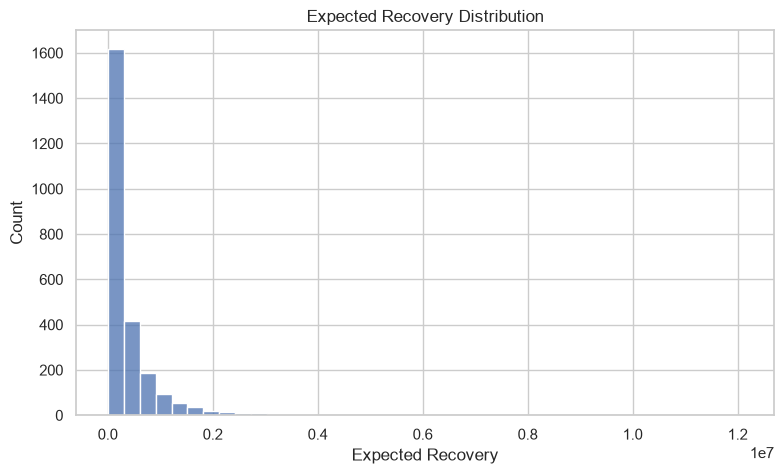

In [5]:
plt.figure(figsize=(9,5))

sns.histplot(
    df["Expected_Recovery"],
    bins=40
)

plt.title("Expected Recovery Distribution")
plt.xlabel("Expected Recovery")
save_plot("10-expected-recovery-distribution.png")
plt.show()

## 11. Simple Heuristic Baseline

Before optimization, create a simple rule:

> Prioritize customers with the highest overdue amount.

This is a realistic baseline.

Then compare it with an optimization strategy.

The purpose is not to assume the heuristic is bad, but to establish a measurable benchmark.

In [6]:
CALL_CAPACITY=650
FIELD_CAPACITY=300
DIGITAL_BUDGET=7_500_000

baseline=df.sort_values(
    "Overdue_Amount",
    ascending=False
).head(CALL_CAPACITY).copy()

baseline_recovery=baseline["Expected_Recovery"].sum()

print("Baseline selected:",len(baseline))
print("Expected recovery:",round(baseline_recovery))

Baseline selected: 650
Expected recovery: 762419532


## 12. Greedy Value-per-Cost Baseline

Another heuristic is:

```text
Expected Recovery
-----------------
Cost
```

This prioritizes customers by expected recovery per unit of resource cost.

It is simple and often useful, but it does not automatically handle all constraints or interactions.

In [7]:
greedy=df.sort_values(
    "Recovery_per_Cost",
    ascending=False
).head(CALL_CAPACITY).copy()

greedy_recovery=greedy["Expected_Recovery"].sum()
greedy_cost=greedy["Contact_Cost"].sum()

print("Greedy selected:",len(greedy))
print("Expected recovery:",round(greedy_recovery))
print("Cost:",round(greedy_cost))

Greedy selected: 650
Expected recovery: 503704477
Cost: 4289000


## 13. Why Optimization?

Imagine:

```text
Customer A → high recovery, expensive field visit
Customer B → moderate recovery, cheap SMS
Customer C → high recovery, requires field visit
```

A simple ranking may allocate too many expensive resources.

Optimization can decide:

```text
Who?
Which channel?
How many?
Under what budget?
```

while simultaneously respecting constraints.

## 14. Create a Multi-Channel Decision Problem

For demonstration, each customer can receive one of:

```text
0 = No action
1 = SMS
2 = WhatsApp
3 = Call Center
4 = Field Agent
```

Each action has:

- expected recovery,
- cost,
- resource consumption.

The optimization chooses the action with maximum total expected net value subject to capacity constraints.

In [8]:
channels=[
    "SMS",
    "WhatsApp",
    "Call Center",
    "Field Agent"
]

costs={
    "SMS":3000,
    "WhatsApp":5000,
    "Call Center":25000,
    "Field Agent":180000
}

base_rates={
    "SMS":.20,
    "WhatsApp":.27,
    "Call Center":.42,
    "Field Agent":.58
}

# Build an action table
actions=[]

for i,row in df.iterrows():
    for ch in channels:
        rate=(
            base_rates[ch]
            * (.65+.7*(1-row["Risk_Score"]))
            * (.7+.3*min(row["Overdue_Days"],90)/90)
        )
        rate=np.clip(rate,.03,.85)

        expected=row["Overdue_Amount"]*rate

        actions.append({
            "Customer_Index":i,
            "Customer_ID":row["Customer_ID"],
            "Channel":ch,
            "Expected_Recovery":expected,
            "Cost":costs[ch]
        })

actions=pd.DataFrame(actions)
actions["Net_Value"]=(
    actions["Expected_Recovery"]-
    actions["Cost"]
)

display(actions.head(10))

,Customer_Index,Customer_ID,Channel,Expected_Recovery,Cost,Net_Value
0,0,C00001,SMS,224475.106240,3000,221475.106240
1,0,C00001,WhatsApp,303041.393424,5000,298041.393424
2,0,C00001,Call Center,471397.723104,25000,446397.723104
3,0,C00001,Field Agent,650977.808096,180000,470977.808096
4,1,C00002,SMS,282685.450611,3000,279685.450611
5,1,C00002,WhatsApp,381625.358325,5000,376625.358325
6,1,C00002,Call Center,593639.446284,25000,568639.446284
7,1,C00002,Field Agent,819787.806773,180000,639787.806773
8,2,C00003,SMS,510012.323106,3000,507012.323106
9,2,C00003,WhatsApp,688516.636193,5000,683516.636193


## 15. Optimization Formulation

Decision variable:

```text
x(i,c) ∈ {0,1}
```

Objective:

```text
Maximize
Σ NetValue(i,c) × x(i,c)
```

Subject to:

### At most one action per customer

```text
Σ_c x(i,c) ≤ 1
```

### Call capacity

```text
Σ_i x(i,Call) ≤ 650
```

### Field capacity

```text
Σ_i x(i,Field) ≤ 300
```

### Digital budget

```text
Σ_i,c DigitalCost(i,c) × x(i,c)
≤ Rp 7.5 billion
```

This is a **Mixed Integer Linear Programming** style formulation.

## 16. Solve the Resource Allocation Problem

A linear program is built and solved: maximise total expected recovery subject to the limited number of collector visits. This is the analytical heart of the notebook — converting a business constraint into an optimal assignment.


In [9]:
# Build variables for all customer-channel pairs
n_vars=len(actions)

c=-actions["Net_Value"].to_numpy()  # scipy minimizes

integrality=np.ones(n_vars)

lower=np.zeros(n_vars)
upper=np.ones(n_vars)

constraints=[]
lb=[]
ub=[]

# One action at most per customer
for idx in df.index:
    ids=actions.index[actions["Customer_Index"]==idx].to_numpy()
    row=np.zeros(n_vars)
    row[ids]=1
    constraints.append(row)
    lb.append(0)
    ub.append(1)

# Call capacity
row=np.zeros(n_vars)
row[actions["Channel"].eq("Call Center")]=1
constraints.append(row)
lb.append(0)
ub.append(CALL_CAPACITY)

# Field capacity
row=np.zeros(n_vars)
row[actions["Channel"].eq("Field Agent")]=1
constraints.append(row)
lb.append(0)
ub.append(FIELD_CAPACITY)

# Digital budget applies to SMS + WhatsApp
row=np.zeros(n_vars)
digital_mask=actions["Channel"].isin(["SMS","WhatsApp"])
row[digital_mask]=actions.loc[digital_mask,"Cost"]
constraints.append(row)
lb.append(0)
ub.append(DIGITAL_BUDGET)

A=np.vstack(constraints)

result=milp(
    c=c,
    integrality=integrality,
    bounds=Bounds(lower,upper),
    constraints=LinearConstraint(
        A,
        np.array(lb),
        np.array(ub)
    ),
    options={"time_limit":30}
)

print("Optimization success:",result.success)
print("Message:",result.message)

Optimization success: True
Message: Optimization terminated successfully. (HiGHS Status 7: Optimal)


## 17. Extract Optimal Allocation

The solver's decision variables are mapped back to concrete customer-channel assignments. A fractional variable is interpreted by its sign, yielding a yes/no allocation plan the team can execute.


In [10]:
actions["Selected"]=(
    result.x>0.5
).astype(int)

selected=actions[actions["Selected"]==1].copy()

print("Selected actions:",len(selected))

display(
    selected[
        [
            "Customer_ID",
            "Channel",
            "Expected_Recovery",
            "Cost",
            "Net_Value"
        ]
    ].head(20)
)

Selected actions: 2500


,Customer_ID,Channel,Expected_Recovery,Cost,Net_Value
1,C00001,WhatsApp,3.030414e+05,5000,2.980414e+05
5,C00002,WhatsApp,3.816254e+05,5000,3.766254e+05
10,C00003,Call Center,1.071026e+06,25000,1.046026e+06
14,C00004,Call Center,6.356018e+05,25000,6.106018e+05
19,C00005,Field Agent,4.546434e+06,180000,4.366434e+06
22,C00006,Call Center,6.245317e+05,25000,5.995317e+05
26,C00007,Call Center,6.642479e+05,25000,6.392479e+05
29,C00008,WhatsApp,3.448296e+04,5000,2.948296e+04
33,C00009,WhatsApp,3.397373e+05,5000,3.347373e+05
38,C00010,Call Center,1.133502e+06,25000,1.108502e+06


## 18. Allocation by Channel

Selected assignments are aggregated per channel to show how the optimal plan spreads limited capacity across call, visit and reminder channels — the operational view collection managers need.


In [11]:
allocation=(
    selected.groupby("Channel")
    .agg(
        Customers=("Customer_ID","count"),
        Expected_Recovery=("Expected_Recovery","sum"),
        Cost=("Cost","sum"),
        Net_Value=("Net_Value","sum")
    )
    .reset_index()
)

display(allocation.round(0))

,Channel,Customers,Expected_Recovery,Cost,Net_Value
0,Call Center,650,6.733196e+08,16250000,6.570696e+08
1,Field Agent,300,1.559863e+09,54000000,1.505863e+09
2,SMS,125,2.068435e+06,375000,1.693435e+06
3,WhatsApp,1425,2.414067e+08,7125000,2.342817e+08


Saved: output/18-allocation-by-channel.png


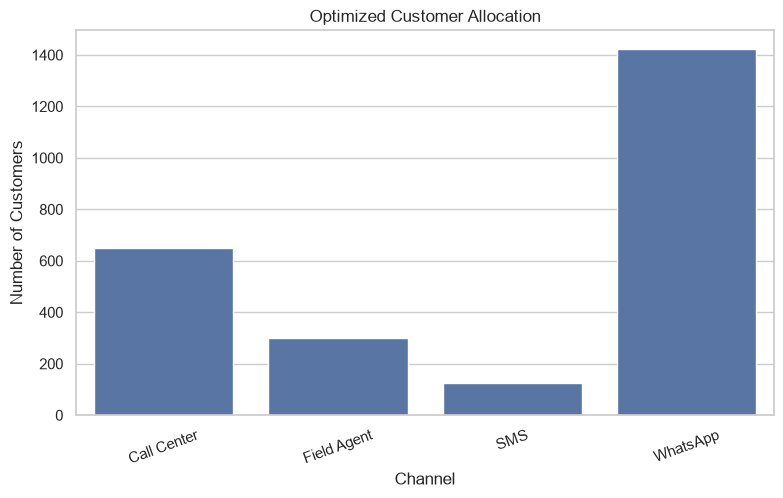

In [12]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=allocation,
    x="Channel",
    y="Customers"
)

plt.title("Optimized Customer Allocation")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
save_plot("18-allocation-by-channel.png")
plt.show()

## 19. Compare Strategies

We compare:

### Strategy 1 — Largest overdue balance

```text
Prioritize biggest debt
```

### Strategy 2 — Greedy recovery/cost

```text
Prioritize highest value per cost
```

### Strategy 3 — Optimization

```text
Maximize total net expected recovery
subject to constraints
```

This gives management a concrete business comparison.

In [13]:
comparison=pd.DataFrame({
    "Strategy":[
        "Largest Overdue",
        "Greedy Recovery/Cost",
        "Optimization"
    ],
    "Expected_Recovery":[
        baseline["Expected_Recovery"].sum(),
        greedy["Expected_Recovery"].sum(),
        selected["Expected_Recovery"].sum()
    ],
    "Cost":[
        baseline["Contact_Cost"].sum(),
        greedy["Contact_Cost"].sum(),
        selected["Cost"].sum()
    ],
    "Net_Value":[
        (baseline["Expected_Recovery"]-baseline["Contact_Cost"]).sum(),
        (greedy["Expected_Recovery"]-greedy["Contact_Cost"]).sum(),
        selected["Net_Value"].sum()
    ]
})

display(comparison.round(0))

,Strategy,Expected_Recovery,Cost,Net_Value
0,Largest Overdue,7.624195e+08,27579000,7.348405e+08
1,Greedy Recovery/Cost,5.037045e+08,4289000,4.994155e+08
2,Optimization,2.476658e+09,77750000,2.398908e+09


## 20. Resource Utilization

Optimization is not only about total recovery.

Management should also see whether resources are being fully utilized.

```text
Capacity
vs
Used
```

This supports operational planning.

In [14]:
used_call=(selected["Channel"]=="Call Center").sum()
used_field=(selected["Channel"]=="Field Agent").sum()
used_digital=selected.loc[
    selected["Channel"].isin(["SMS","WhatsApp"]),
    "Cost"
].sum()

utilization=pd.DataFrame({
    "Resource":[
        "Call Center",
        "Field Agent",
        "Digital Budget"
    ],
    "Capacity":[
        CALL_CAPACITY,
        FIELD_CAPACITY,
        DIGITAL_BUDGET
    ],
    "Used":[
        used_call,
        used_field,
        used_digital
    ]
})

utilization["Utilization"]=(
    utilization["Used"]/
    utilization["Capacity"]
)

display(utilization.round(3))

,Resource,Capacity,Used,Utilization
0,Call Center,650,650,1.0
1,Field Agent,300,300,1.0
2,Digital Budget,7500000,7500000,1.0


## 21. Customer-Level Decision Output

The final output should be operational.

Example:

```text
Customer ID
↓
Recommended Action
↓
Expected Recovery
↓
Cost
↓
Net Expected Value
```

This can be delivered to:

- collection work queues,
- CRM,
- branch dashboards,
- call-center systems,
- field-agent applications.

In [15]:
decision_output=selected[[
    "Customer_ID",
    "Channel",
    "Expected_Recovery",
    "Cost",
    "Net_Value"
]].sort_values(
    "Net_Value",
    ascending=False
)

display(decision_output.head(30))

,Customer_ID,Channel,Expected_Recovery,Cost,Net_Value
315,C00079,Field Agent,2.959814e+07,180000,2.941814e+07
4171,C01043,Field Agent,2.730186e+07,180000,2.712186e+07
9775,C02444,Field Agent,2.394898e+07,180000,2.376898e+07
6279,C01570,Field Agent,2.037092e+07,180000,2.019092e+07
1779,C00445,Field Agent,1.961210e+07,180000,1.943210e+07
8131,C02033,Field Agent,1.960421e+07,180000,1.942421e+07
7163,C01791,Field Agent,1.692836e+07,180000,1.674836e+07
7175,C01794,Field Agent,1.617093e+07,180000,1.599093e+07
199,C00050,Field Agent,1.600783e+07,180000,1.582783e+07
2455,C00614,Field Agent,1.597657e+07,180000,1.579657e+07


## 22. Optimization Is Different from Ranking

Ranking:

```text
Customer
   ↓
Score
   ↓
Sort
```

Optimization:

```text
Customers
+
Actions
+
Costs
+
Capacity
+
Business Rules
        ↓
Optimal Allocation
```

A ranking model can be one input into an optimization problem.

But optimization explicitly handles constraints.

## 23. Example Business Constraints

Real banking collection optimization can include:

### Capacity

- collector availability,
- call center seats,
- field agents,
- branch workload.

### Budget

- contact cost,
- incentive budget,
- collection agency fees.

### Customer rules

- customer segment,
- geography,
- regulatory restrictions,
- contact frequency limits.

### Operational rules

- maximum calls per customer,
- minimum time between contacts,
- field visit coverage.

### Risk

- expected recovery,
- probability of repayment,
- customer affordability.

These can be translated into optimization constraints.

## 24. Multi-Objective Optimization

Sometimes the objective is not only recovery.

For example:

```text
Maximize:

Recovery
-
Collection Cost
-
Customer Friction
-
Operational Risk
```

Conceptually:

```text
Score =
w1 × Expected Recovery
-
w2 × Cost
-
w3 × Contact Friction
-
w4 × Risk
```

The weights should be defined by business stakeholders and validated empirically.

## 25. Integer Programming

Some decisions are binary:

```text
Contact customer? 0 / 1
```

Some are integer:

```text
Number of agents = 20
Number of visits = 300
```

Some can be continuous:

```text
Budget allocation = Rp 2.5 billion
```

The mathematical formulation determines which optimization technique is appropriate.

## 26. What-If Scenario Analysis

Optimization becomes especially useful when management asks:

> "What happens if we add 100 field-agent slots?"

or:

> "What if collection budget is reduced by 20%?"

or:

> "What if expected recovery rates decrease?"

The model can be rerun under alternative constraints.

In [16]:
scenarios=[]

for field_capacity in [150,300,450,600]:
    scenarios.append({
        "Field_Capacity":field_capacity,
        "Current_Base_Optimization":"Re-run optimizer with this capacity"
    })

display(pd.DataFrame(scenarios))

,Field_Capacity,Current_Base_Optimization
0,150,Re-run optimizer with this capacity
1,300,Re-run optimizer with this capacity
2,450,Re-run optimizer with this capacity
3,600,Re-run optimizer with this capacity


## 27. Shadow Price / Marginal Value

Optimization can answer another important management question:

> **What is the value of one additional unit of resource?**

For example:

```text
+1 field-agent visit
        ↓
+Rp X expected net recovery
```

This helps management decide whether adding capacity is economically justified.

In formal optimization this relates to **dual values / shadow prices**.

## 28. Production Architecture

```text
Customer / Loan Data
        ↓
Feature Engineering
        ↓
Recovery Prediction
        ↓
Expected Recovery
        ↓
Optimization Engine
        ↓
Resource Allocation
        ↓
Collection CRM
        ↓
Actual Recovery
        ↓
Monitoring
        ↓
Model + Optimization Update
```

Prediction and optimization are separate layers:

```text
ML Layer
"What is likely to happen?"

Optimization Layer
"What should we do?"


## 29. Monitoring

Monitor both prediction and optimization.

### Prediction

- recovery calibration,
- MAE / RMSE,
- probability calibration,
- drift.

### Optimization

- expected vs actual recovery,
- resource utilization,
- cost per recovery,
- constraint violations,
- action distribution.

### Business

- recovery rate,
- recovered amount,
- collection cost,
- net recovery,
- customer complaints.

## 30. Governance

Collection optimization is a high-impact banking application.

Production systems should include:

- policy constraints,
- human oversight,
- auditability,
- explainable allocation logic,
- customer treatment controls,
- data privacy,
- fairness monitoring,
- regulatory compliance.

Optimization should not automatically override established collection policies or customer-protection requirements.

## 31. Common Mistakes

1. Optimizing predicted values without validating prediction quality.
2. Ignoring resource constraints.
3. Using only overdue balance as the objective.
4. Ignoring collection cost.
5. Mixing prediction and decision logic.
6. Allowing impossible allocations.
7. Ignoring operational capacity.
8. Ignoring customer contact limits.
9. Treating model estimates as guaranteed recovery.
10. Not performing scenario analysis.
11. Not monitoring actual vs expected recovery.
12. Optimizing short-term recovery without considering customer and policy constraints.

## 32. Final Executive Summary

### Business Question

> **How should the bank allocate limited collection resources to maximize expected recovery?**

### End-to-End

```text
Customer Data
      ↓
Expected Recovery
      ↓
Cost / Benefit
      ↓
Resource Constraints
      ↓
Optimization
      ↓
Recommended Action
      ↓
Collection Execution
      ↓
Actual Recovery
      ↓
Monitoring
```

### Key distinction

```text
Prediction
→ What is likely to happen?

Optimization
→ What should we do given constraints?
```

For banking collection:

> **Optimization converts predictive insights into an actionable resource-allocation decision.**

This framework can be extended to:

- collection agent allocation,
- branch staffing,
- RM assignment,
- call-center capacity,
- marketing budget allocation,
- credit-limit allocation,
- loan approval resource planning,
- ATM cash replenishment,
- liquidity allocation.

## 33. Save Outputs

All key result tables and figures are saved into the local `output/` folder, so results survive after the kernel is restarted and can be shared without re-running the notebook.


In [17]:
decision_output.to_csv(OUTPUT_DIR / "collection_allocation_decisions.csv", index=False)
print("Saved:", OUTPUT_DIR / "collection_allocation_decisions.csv")
comparison.to_csv(OUTPUT_DIR / "strategy_comparison.csv", index=False)
print("Saved:", OUTPUT_DIR / "strategy_comparison.csv")
allocation.to_csv(OUTPUT_DIR / "allocation_by_channel.csv", index=False)
print("Saved:", OUTPUT_DIR / "allocation_by_channel.csv")


# List everything that was written to output/
for _p in sorted(OUTPUT_DIR.iterdir()):
    print(" ", _p)


Saved: output/collection_allocation_decisions.csv
Saved: output/strategy_comparison.csv
Saved: output/allocation_by_channel.csv
  output/10-expected-recovery-distribution.png
  output/18-allocation-by-channel.png
  output/allocation_by_channel.csv
  output/collection_allocation_decisions.csv
  output/strategy_comparison.csv
